Redshift failure rate for exposures with depth between 750s and 1250s

In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
deep = Table(fitsio.read('/global/cfs/cdirs/desi/survey/catalogs/SV1/redshift_comps/blanc/v2/LRG/alltiles_LRGzinfo.fits'))
print(len(deep), len(np.unique(deep['TARGETID'])))

mask = deep['subset']=='deep'
print(np.sum(mask))
mask &= deep['TARGETS']=='QSO+LRG'
print(np.sum(mask))

deep = deep[mask]
print(len(deep), len(np.unique(deep['TARGETID'])))

# Remove FIBERSTATUS!=0 fibers
mask = deep['FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Remove "no data" fibers
mask = deep['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Require a minimum depth for the deep coadd
min_depth = 4000.
mask = deep['R_DEPTH_EBVAIR']>min_depth
print(np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
deep = deep[mask]

print(len(deep), len(np.unique(deep['TARGETID'])))

deep.rename_columns(['B_DEPTH', 'R_DEPTH', 'Z_DEPTH', 'B_DEPTH_EBVAIR', 'R_DEPTH_EBVAIR', 'Z_DEPTH_EBVAIR'],
    ['B_DEPTH_deep', 'R_DEPTH_deep', 'Z_DEPTH_deep', 'B_DEPTH_EBVAIR_deep', 'R_DEPTH_EBVAIR_deep', 'Z_DEPTH_EBVAIR_deep'])

79651 14100
14530
10113
10113 10113
FIBERSTATUS 8364 1749 0.1729457134381489
No data 8364 0 0.0
5942 2422 0.7104256336681014
5942 5942


__Add sweep columns__

In [4]:
# Snippets taken from desitarget

from desitarget.targets import encode_targetid

def decode_sweep_name(sweepname):
    sweepname = os.path.basename(sweepname)

    ramin, ramax = float(sweepname[6:9]), float(sweepname[14:17])
    decmin, decmax = float(sweepname[10:13]), float(sweepname[18:21])

    if sweepname[9] == 'm':
        decmin *= -1
    if sweepname[17] == 'm':
        decmax *= -1

    return [ramin, ramax, decmin, decmax]

def is_in_box(objs, radecbox, ra_col='RA', dec_col='DEC'):

    ramin, ramax, decmin, decmax = radecbox

    # ADM check for some common mistakes.
    if decmin < -90. or decmax > 90. or decmax <= decmin or ramax <= ramin:
        msg = "Strange input: [ramin, ramax, decmin, decmax] = {}".format(radecbox)
        log.critical(msg)
        raise ValueError(msg)

    ii = ((objs[ra_col] >= ramin) & (objs[ra_col] < ramax)
          & (objs[dec_col] >= decmin) & (objs[dec_col] < decmax))

    return ii

In [5]:
ls_columns = ['MW_TRANSMISSION_G', 'MW_TRANSMISSION_R', 'MW_TRANSMISSION_Z', 'MW_TRANSMISSION_W1', 'MW_TRANSMISSION_W2']

# Ignore any possible north/south overlap (targetid automatically handles the north/south split)

sweep_fn_list = []
for field in ['north', 'south']:
    sweep_dir = '/global/cfs/cdirs/cosmo/data/legacysurvey/dr9/{}/sweep/9.0'.format(field)
    sweep_fn_list += sorted(glob.glob(os.path.join(sweep_dir, '*.fits')))
sweep_fn_list = np.array(sweep_fn_list)

sweep_radec_list = [decode_sweep_name(sweep_fn) for sweep_fn in sweep_fn_list]
mask = np.array([np.any(is_in_box(deep, sweep_radec, ra_col='TARGET_RA', dec_col='TARGET_DEC')) for sweep_radec in sweep_radec_list])
print(np.sum(mask))
sweep_fn_list = sweep_fn_list[mask]

ls_stack = []
for sweep_fn in sweep_fn_list:
    ls = Table(fitsio.read(sweep_fn, columns=['OBJID', 'BRICKID', 'RELEASE']))
    targetid = encode_targetid(ls['OBJID'], ls['BRICKID'], ls['RELEASE'])
    idx = np.where(np.in1d(targetid, deep['TARGETID']))[0]
    if len(idx)==0:
        continue
    targetid = targetid[idx]
    ls = Table(fitsio.read(sweep_fn, rows=idx, columns=ls_columns))
    ls['TARGETID'] = targetid
    # pz_fn = sweep_fn.replace('sweep/9.0/', 'sweep/9.0-photo-z/').replace('.fits', '-pz.fits')
    # pz = Table(fitsio.read(pz_fn, rows=idx))
    # if '/south/sweep/' in sweep_fn:
    #     pz['field'] = 'south'
    # else:
    #     pz['field'] = 'north'
    # pz.remove_columns(['OBJID', 'BRICKID', 'RELEASE'])
    # ls = hstack([ls, pz])
    ls_stack.append(ls)
ls = vstack(ls_stack)
print(len(deep), len(ls))

# # This only works if the objects are unique
# _, idx1, idx2 = np.intersect1d(deep['TARGETID'], ls['TARGETID'], return_indices=True)
# print(len(deep), len(idx1), len(deep)-len(idx1))
# deep = deep[idx1]
# ls = ls[idx2]

deep = join(deep, ls, keys='TARGETID')

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    deep['gmag'] = 22.5 - 2.5*np.log10(deep['FLUX_G']/deep['MW_TRANSMISSION_G'])
    deep['rmag'] = 22.5 - 2.5*np.log10(deep['FLUX_R']/deep['MW_TRANSMISSION_R'])
    deep['zmag'] = 22.5 - 2.5*np.log10(deep['FLUX_Z']/deep['MW_TRANSMISSION_Z'])
    deep['w1mag'] = 22.5 - 2.5*np.log10(deep['FLUX_W1']/deep['MW_TRANSMISSION_W1'])
    deep['w2mag'] = 22.5 - 2.5*np.log10(deep['FLUX_W2']/deep['MW_TRANSMISSION_W2'])
    deep['gfibermag'] = 22.5 - 2.5*np.log10(deep['FIBERFLUX_G']/deep['MW_TRANSMISSION_G'])
    deep['rfibermag'] = 22.5 - 2.5*np.log10(deep['FIBERFLUX_R']/deep['MW_TRANSMISSION_R'])
    deep['zfibermag'] = 22.5 - 2.5*np.log10(deep['FIBERFLUX_Z']/deep['MW_TRANSMISSION_Z'])

10
5942 5942


__Single exposure redshifts__

In [6]:
zbest = Table(fitsio.read('/global/cfs/cdirs/desi/survey/catalogs/SV1/redshift_comps/blanc/v2/LRG/alltiles_LRGzinfo_1exp.fits'))
print(len(zbest), len(np.unique(zbest['TARGETID'])))

mask = np.in1d(zbest['TARGETID'], deep['TARGETID'])
mask &= np.in1d(zbest['TILEID'], np.unique(deep['TILEID']))
zbest = zbest[mask]
print(len(zbest), len(np.unique(zbest['TARGETID'])))

mask = (zbest['FIBERSTATUS']==0) & (zbest['ZWARN'] & 2**9==0)
print(np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
zbest = zbest[mask]

zbest = join(zbest, deep[['TARGETID', 'B_DEPTH_deep', 'R_DEPTH_deep', 'Z_DEPTH_deep', 'B_DEPTH_EBVAIR_deep', 'R_DEPTH_EBVAIR_deep', 'Z_DEPTH_EBVAIR_deep', 'gmag', 'rmag', 'zmag', 'w1mag', 'w2mag', 'gfibermag', 'rfibermag', 'zfibermag']], keys='TARGETID')

198699 14100
80626 5942
76923 3703 0.045928112519534645


__Depth cut__

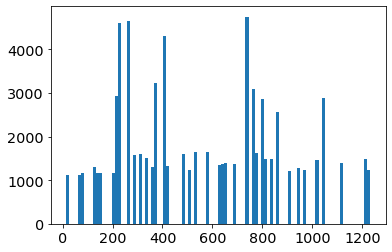

25298 0.3288743288743289


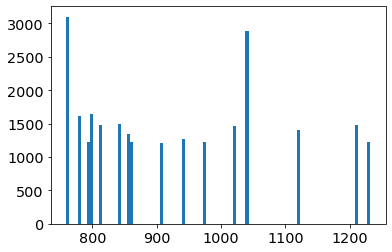

926.7776
862.9997


In [7]:
plt.hist(zbest['R_DEPTH_EBVAIR'], 100)
plt.show()

mask = (zbest['R_DEPTH_EBVAIR'] > 750) & (zbest['R_DEPTH_EBVAIR'] < 1250)
print(np.sum(mask), np.sum(mask)/len(mask))
zbest = zbest[mask]

plt.hist(zbest['R_DEPTH_EBVAIR'], 100)
plt.show()

print(np.mean(zbest['R_DEPTH_EBVAIR']))
print(np.median(zbest['R_DEPTH_EBVAIR']))

In [8]:
print(len(zbest), len(np.unique(zbest['TARGETID'])))

25298 5942


In [9]:
lrg_opt = zbest['SV1_DESI_TARGET'] & 2**3>0
lrg_ir = zbest['SV1_DESI_TARGET'] & 2**4>0
lrg_sv = zbest['SV1_DESI_TARGET'] & 2**0>0
lrg_sv_opt = zbest['SV1_DESI_TARGET'] & 2**5>0
lrg_sv_ir = zbest['SV1_DESI_TARGET'] & 2**6>0
print(np.sum(lrg_opt))
print(np.sum(lrg_ir))
print(np.sum(lrg_sv))
print(np.sum(lrg_sv_opt))
print(np.sum(lrg_sv_ir))

6686
6925
25298
18693
21864


In [10]:
print('Total # exposures in this analysis:', len(np.unique(zbest['EXPID'])))
t = Table()
t['TILEID'], t['count'] = np.unique(zbest['TILEID'], return_counts=True)
t['n_exp'] = 0
for index, tileid in enumerate(t['TILEID']):
    mask = zbest['TILEID']==tileid
    t['n_exp'][index] = len(np.unique(zbest['EXPID'][mask]))
t

Total # exposures in this analysis: 18


TILEID,count,n_exp
int32,int64,int64
80607,10187,7
80609,4902,3
80620,4078,3
80622,6131,5


In [11]:
mask_zwarn = (zbest['ZWARN_deep']==0)

# Not repeatable
zdiff_threshold = 0.0033
mask_fail = np.abs((zbest['Z'] - zbest['Z_deep'])/(1 + zbest['Z_deep'])) > zdiff_threshold
print(np.sum(mask_fail), np.sum(mask_fail)/len(mask_fail))
# Also include objects with ZWARN!=0 in the deep coadds
mask_fail |= (~mask_zwarn)
print(np.sum(mask_fail), np.sum(mask_fail)/len(mask_fail))

1735 0.0685824966400506
1787 0.07063799509842675


---------

LRG_OPT: 1.2% (82/6686)
LRG_SV_OPT: 5.9% (1109/18693)

LRG_SV_OPT with zfiber<21.7: 2.2% (306/14172)
0.3<z<0.9: 5330 10953 2.05
0.9<z<1.1: 944 2004 2.12

LRG_SV_OPT with zfiber<21.5: 1.3% (149/11803)
0.3<z<0.9: 5330 9654 1.81
0.9<z<1.1: 944 1196 1.27



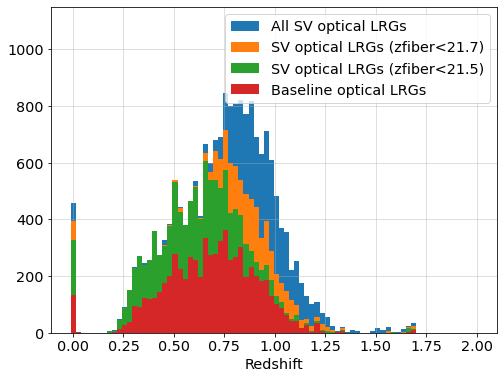

In [12]:
print('LRG_OPT: {:.1f}% ({}/{})'.format(np.sum(lrg_opt & mask_fail)/np.sum(lrg_opt)*100, np.sum(lrg_opt & mask_fail), np.sum(lrg_opt)))
print('LRG_SV_OPT: {:.1f}% ({}/{})'.format(np.sum(lrg_sv_opt & mask_fail)/np.sum(lrg_sv_opt)*100, np.sum(lrg_sv_opt & mask_fail), np.sum(lrg_sv_opt)))
print()

###############################################################################################################

plt.figure(figsize=(8, 6))
plt.hist(zbest['Z_deep'][lrg_sv_opt & mask_zwarn], bins=80, range=(-0.01, 2.0), label='All SV optical LRGs', zorder=0)

zfiber_lim = 21.7
mask_zfiber = zbest['zfibermag']<zfiber_lim
lrg_new = lrg_sv_opt & mask_zfiber
print('LRG_SV_OPT with zfiber<{:g}: {:.1f}% ({}/{})'.format(zfiber_lim, np.sum(lrg_new & mask_fail)/np.sum(lrg_new)*100, np.sum(lrg_new & mask_fail), np.sum(lrg_new)))
z_mask = (zbest['Z_deep']>0.3) & (zbest['Z_deep']<0.9)
print('0.3<z<0.9: {} {} {:.2f}'.format(np.sum(lrg_opt & mask_zwarn & z_mask), np.sum(lrg_new & mask_zwarn & z_mask),
     np.sum(lrg_new & mask_zwarn & z_mask)/np.sum(lrg_opt & mask_zwarn & z_mask)))
z_mask = (zbest['Z_deep']>0.9) & (zbest['Z_deep']<1.1)
print('0.9<z<1.1: {} {} {:.2f}'.format(np.sum(lrg_opt & mask_zwarn & z_mask), np.sum(lrg_new & mask_zwarn & z_mask),
     np.sum(lrg_new & mask_zwarn & z_mask)/np.sum(lrg_opt & mask_zwarn & z_mask)))
print()
plt.hist(zbest['Z_deep'][lrg_new & mask_zwarn], bins=80, range=(-0.01, 2.0), label='SV optical LRGs (zfiber<{:g})'.format(zfiber_lim), zorder=2)

zfiber_lim = 21.5
mask_zfiber = zbest['zfibermag']<zfiber_lim
lrg_new = lrg_sv_opt & mask_zfiber
print('LRG_SV_OPT with zfiber<{:g}: {:.1f}% ({}/{})'.format(zfiber_lim, np.sum(lrg_new & mask_fail)/np.sum(lrg_new)*100, np.sum(lrg_new & mask_fail), np.sum(lrg_new)))
z_mask = (zbest['Z_deep']>0.3) & (zbest['Z_deep']<0.9)
print('0.3<z<0.9: {} {} {:.2f}'.format(np.sum(lrg_opt & mask_zwarn & z_mask), np.sum(lrg_new & mask_zwarn & z_mask),
     np.sum(lrg_new & mask_zwarn & z_mask)/np.sum(lrg_opt & mask_zwarn & z_mask)))
z_mask = (zbest['Z_deep']>0.9) & (zbest['Z_deep']<1.1)
print('0.9<z<1.1: {} {} {:.2f}'.format(np.sum(lrg_opt & mask_zwarn & z_mask), np.sum(lrg_new & mask_zwarn & z_mask),
     np.sum(lrg_new & mask_zwarn & z_mask)/np.sum(lrg_opt & mask_zwarn & z_mask)))
print()
plt.hist(zbest['Z_deep'][lrg_new & mask_zwarn], bins=80, range=(-0.01, 2.0), label='SV optical LRGs (zfiber<{:g})'.format(zfiber_lim), zorder=2)

plt.hist(zbest['Z_deep'][lrg_opt & mask_zwarn], bins=80, range=(-0.01, 2.0), label='Baseline optical LRGs', zorder=3)
plt.xlabel('Redshift')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.ylim(ymax=1150)
plt.show()

LRG_IR: 2.1% (143/6925)
LRG_SV_IR: 7.5% (1642/21864)

LRG_SV_IR with zfiber<21.7: 2.7% (416/15145)
0.3<z<0.9: 5392 11223 2.08
0.9<z<1.1: 816 2130 2.61

LRG_SV_IR with zfiber<21.5: 1.8% (217/12293)
0.3<z<0.9: 5392 9566 1.77
0.9<z<1.1: 816 1227 1.50



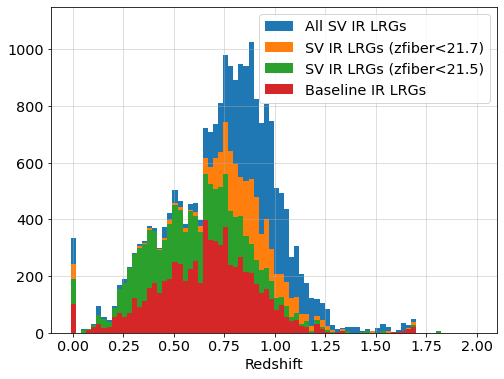

In [13]:
print('LRG_IR: {:.1f}% ({}/{})'.format(np.sum(lrg_ir & mask_fail)/np.sum(lrg_ir)*100, np.sum(lrg_ir & mask_fail), np.sum(lrg_ir)))
print('LRG_SV_IR: {:.1f}% ({}/{})'.format(np.sum(lrg_sv_ir & mask_fail)/np.sum(lrg_sv_ir)*100, np.sum(lrg_sv_ir & mask_fail), np.sum(lrg_sv_ir)))
print()

###############################################################################################################

plt.figure(figsize=(8, 6))
plt.hist(zbest['Z_deep'][lrg_sv_ir & mask_zwarn], bins=80, range=(-0.01, 2.0), label='All SV IR LRGs', zorder=0)

zfiber_lim = 21.7
mask_zfiber = zbest['zfibermag']<zfiber_lim
lrg_new = lrg_sv_ir & mask_zfiber
print('LRG_SV_IR with zfiber<{:g}: {:.1f}% ({}/{})'.format(zfiber_lim, np.sum(lrg_new & mask_fail)/np.sum(lrg_new)*100, np.sum(lrg_new & mask_fail), np.sum(lrg_new)))
z_mask = (zbest['Z_deep']>0.3) & (zbest['Z_deep']<0.9)
print('0.3<z<0.9: {} {} {:.2f}'.format(np.sum(lrg_ir & mask_zwarn & z_mask), np.sum(lrg_new & mask_zwarn & z_mask),
     np.sum(lrg_new & mask_zwarn & z_mask)/np.sum(lrg_ir & mask_zwarn & z_mask)))
z_mask = (zbest['Z_deep']>0.9) & (zbest['Z_deep']<1.1)
print('0.9<z<1.1: {} {} {:.2f}'.format(np.sum(lrg_ir & mask_zwarn & z_mask), np.sum(lrg_new & mask_zwarn & z_mask),
     np.sum(lrg_new & mask_zwarn & z_mask)/np.sum(lrg_ir & mask_zwarn & z_mask)))
print()
plt.hist(zbest['Z_deep'][lrg_new & mask_zwarn], bins=80, range=(-0.01, 2.0), label='SV IR LRGs (zfiber<{:g})'.format(zfiber_lim), zorder=1)

zfiber_lim = 21.5
mask_zfiber = zbest['zfibermag']<zfiber_lim
lrg_new = lrg_sv_ir & mask_zfiber
print('LRG_SV_IR with zfiber<{:g}: {:.1f}% ({}/{})'.format(zfiber_lim, np.sum(lrg_new & mask_fail)/np.sum(lrg_new)*100, np.sum(lrg_new & mask_fail), np.sum(lrg_new)))
z_mask = (zbest['Z_deep']>0.3) & (zbest['Z_deep']<0.9)
print('0.3<z<0.9: {} {} {:.2f}'.format(np.sum(lrg_ir & mask_zwarn & z_mask), np.sum(lrg_new & mask_zwarn & z_mask),
     np.sum(lrg_new & mask_zwarn & z_mask)/np.sum(lrg_ir & mask_zwarn & z_mask)))
z_mask = (zbest['Z_deep']>0.9) & (zbest['Z_deep']<1.1)
print('0.9<z<1.1: {} {} {:.2f}'.format(np.sum(lrg_ir & mask_zwarn & z_mask), np.sum(lrg_new & mask_zwarn & z_mask),
     np.sum(lrg_new & mask_zwarn & z_mask)/np.sum(lrg_ir & mask_zwarn & z_mask)))
print()
plt.hist(zbest['Z_deep'][lrg_new & mask_zwarn], bins=80, range=(-0.01, 2.0), label='SV IR LRGs (zfiber<{:g})'.format(zfiber_lim), zorder=2)

plt.hist(zbest['Z_deep'][lrg_ir & mask_zwarn], bins=80, range=(-0.01, 2.0), label='Baseline IR LRGs', zorder=3)
plt.xlabel('Redshift')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.ylim(ymax=1150)
plt.show()

-----
## zmag-version of the baseline selection

__Sanity check that I can reproduce the baseline optical selection:__

In [24]:
# South
lrg_mask_south = zbest['zmag'] - zbest['w1mag'] > 0.8 * (zbest['rmag']-zbest['zmag']) - 0.6  # non-stellar cut
lrg_mask_south &= (zbest['zfibermag'] < 21.5)                   # faint limit

lowz_cut = (zbest['gmag'] - zbest['w1mag'] > 2.6) & (zbest['gmag'] - zbest['rmag'] > 1.4) # low-z cut
lowz_cut |= (zbest['rmag']-zbest['w1mag']) > 1.8                   # ignore low-z cut for faint objects
lrg_mask_south &= lowz_cut

lrg_mask_south &= zbest['rmag'] - zbest['zmag'] > (zbest['zmag'] - 16.83) * 0.45       # sliding optical cut
lrg_mask_south &= zbest['rmag'] - zbest['zmag'] > (zbest['zmag'] - 13.80) * 0.19       # low-z sliding optical cut

# North
lrg_mask_north = zbest['zmag'] - zbest['w1mag'] > 0.8 * (zbest['rmag']-zbest['zmag']) - 0.6  # non-stellar cut
lrg_mask_north &= (zbest['zfibermag'] < 21.5)                     # faint limit

lowz_cut = (zbest['gmag'] - zbest['w1mag'] > 2.67) & (zbest['gmag'] - zbest['rmag'] > 1.45)  # low-z cut
lowz_cut |= (zbest['rmag']-zbest['w1mag']) > 1.85                         # ignore low-z cut for faint objects
lrg_mask_north &= lowz_cut

lrg_mask_north &= zbest['rmag'] - zbest['zmag'] > (zbest['zmag'] - 16.79) * 0.45       # sliding optical cut
lrg_mask_north &= zbest['rmag'] - zbest['zmag'] > (zbest['zmag'] - 13.76) * 0.19  # low-z sliding optical cut

mask_south = zbest['PHOTSYS']=='S'
mask_north = zbest['PHOTSYS']=='N'
lrg_test = (lrg_mask_south & mask_south) | (lrg_mask_north & mask_north)

print(np.all(lrg_opt==lrg_test))

True


__zmag-limited selection__

In [84]:
# South
lrg_mask_south = zbest['zmag'] - zbest['w1mag'] > 0.8 * (zbest['rmag']-zbest['zmag']) - 0.6  # non-stellar cut
lrg_mask_south &= (zbest['zmag'] < 20.7)                   # faint limit

lowz_cut = (zbest['gmag'] - zbest['w1mag'] > 2.6) & (zbest['gmag'] - zbest['rmag'] > 1.4) # low-z cut
lowz_cut |= (zbest['rmag']-zbest['w1mag']) > 1.8                   # ignore low-z cut for faint objects
lrg_mask_south &= lowz_cut

lrg_mask_south &= zbest['rmag'] - zbest['zmag'] > (zbest['zmag'] - 16.83) * 0.45       # sliding optical cut
lrg_mask_south &= zbest['rmag'] - zbest['zmag'] > (zbest['zmag'] - 13.80) * 0.19       # low-z sliding optical cut

# North
lrg_mask_north = zbest['zmag'] - zbest['w1mag'] > 0.8 * (zbest['rmag']-zbest['zmag']) - 0.6  # non-stellar cut
lrg_mask_north &= (zbest['zmag'] < 20.75)                     # faint limit

lowz_cut = (zbest['gmag'] - zbest['w1mag'] > 2.67) & (zbest['gmag'] - zbest['rmag'] > 1.45)  # low-z cut
lowz_cut |= (zbest['rmag']-zbest['w1mag']) > 1.85                         # ignore low-z cut for faint objects
lrg_mask_north &= lowz_cut

lrg_mask_north &= zbest['rmag'] - zbest['zmag'] > (zbest['zmag'] - 16.79) * 0.45       # sliding optical cut
lrg_mask_north &= zbest['rmag'] - zbest['zmag'] > (zbest['zmag'] - 13.76) * 0.19  # low-z sliding optical cut

mask_south = zbest['PHOTSYS']=='S'
mask_north = zbest['PHOTSYS']=='N'
lrg_opt_zmag = (lrg_mask_south & mask_south) | (lrg_mask_north & mask_north)
print(np.sum(lrg_opt_zmag), np.sum(lrg_opt_zmag)/np.sum(lrg_opt))

6738 1.007777445408316


In [85]:
# Overall failure rates
print('Baseline optical LRG with zfiber<21.5: {:.1f}% ({}/{})'.format(np.sum(lrg_opt & mask_fail)/np.sum(lrg_opt)*100, np.sum(lrg_opt & mask_fail), np.sum(lrg_opt)))
print('Baseline optical LRG with zmag<20.7:   {:.1f}% ({}/{})'.format(np.sum(lrg_opt_zmag & mask_fail)/np.sum(lrg_opt_zmag)*100, np.sum(lrg_opt_zmag & mask_fail), np.sum(lrg_opt_zmag)))

Baseline optical LRG with zfiber<21.5: 1.2% (82/6686)
Baseline optical LRG with zmag<20.7:   2.4% (160/6738)


In [79]:
zfiber_limit = 22.
print(np.sum(lrg_opt_zmag & (zbest['zfibermag']>=zfiber_limit)))
lrg_opt_zmag_zfiber = lrg_opt_zmag & (zbest['zfibermag']<zfiber_limit)
print('Baseline optical LRG with zmag<20.7 and zfiber<{:g}:   {:.1f}% ({}/{})'.format(zfiber_limit, np.sum(lrg_opt_zmag_zfiber & mask_fail)/np.sum(lrg_opt_zmag_zfiber)*100, np.sum(lrg_opt_zmag_zfiber & mask_fail), np.sum(lrg_opt_zmag_zfiber)))

108
Baseline optical LRG with zmag<20.7 and zfiber<22:   1.8% (119/6630)


__zmag-limited selection (on deep for plotting redshift histogram)__

In [35]:
# South
lrg_mask_south = deep['zmag'] - deep['w1mag'] > 0.8 * (deep['rmag']-deep['zmag']) - 0.6  # non-stellar cut
lrg_mask_south &= (deep['zmag'] < 20.7)                   # faint limit

lowz_cut = (deep['gmag'] - deep['w1mag'] > 2.6) & (deep['gmag'] - deep['rmag'] > 1.4) # low-z cut
lowz_cut |= (deep['rmag']-deep['w1mag']) > 1.8                   # ignore low-z cut for faint objects
lrg_mask_south &= lowz_cut

lrg_mask_south &= deep['rmag'] - deep['zmag'] > (deep['zmag'] - 16.83) * 0.45       # sliding optical cut
lrg_mask_south &= deep['rmag'] - deep['zmag'] > (deep['zmag'] - 13.80) * 0.19       # low-z sliding optical cut

# North
lrg_mask_north = deep['zmag'] - deep['w1mag'] > 0.8 * (deep['rmag']-deep['zmag']) - 0.6  # non-stellar cut
lrg_mask_north &= (deep['zmag'] < 20.75)                     # faint limit

lowz_cut = (deep['gmag'] - deep['w1mag'] > 2.67) & (deep['gmag'] - deep['rmag'] > 1.45)  # low-z cut
lowz_cut |= (deep['rmag']-deep['w1mag']) > 1.85                         # ignore low-z cut for faint objects
lrg_mask_north &= lowz_cut

lrg_mask_north &= deep['rmag'] - deep['zmag'] > (deep['zmag'] - 16.79) * 0.45       # sliding optical cut
lrg_mask_north &= deep['rmag'] - deep['zmag'] > (deep['zmag'] - 13.76) * 0.19  # low-z sliding optical cut

mask_south = deep['PHOTSYS']=='S'
mask_north = deep['PHOTSYS']=='N'
lrg_opt_zmag = (lrg_mask_south & mask_south) | (lrg_mask_north & mask_north)

lrg_opt_deep = deep['SV1_DESI_TARGET'] & 2**3>0

print(np.sum(lrg_opt_zmag), np.sum(lrg_opt_zmag)/np.sum(lrg_opt_deep))

1559 1.0136540962288687


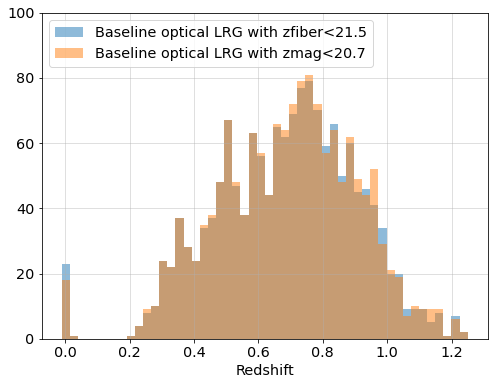

In [39]:
mask_zwarn_deep = (deep['ZWARN']==0)

plt.figure(figsize=(8, 6))
plt.hist(deep['Z'][lrg_opt_deep & mask_zwarn_deep], bins=50, range=(-0.01, 1.25), label='Baseline optical LRG with zfiber<21.5', alpha=0.5)
plt.hist(deep['Z'][lrg_opt_zmag & mask_zwarn_deep], bins=50, range=(-0.01, 1.25), label='Baseline optical LRG with zmag<20.7', alpha=0.5)
plt.xlabel('Redshift')
plt.legend(loc='upper left')
plt.grid(alpha=0.5)
plt.ylim(ymax=100)
plt.show()